IMPORTING LIBRARIES

In [4]:
import pandas as pd
import numpy as np
df = pd.read_csv('/content/Mental Health.csv')
df

,posts,predicted,intensity
0,I know as parent of child with down syndrome t...,negative,-1
1,but in my heart I know this is the future prom...,neutral,0
2,I have mylefibrosis which turn to leukemia the...,negative,-1
3,from one of my health group subject wayne dyer...,neutral,0
4,gmos now link to leukemia http nsnbc I 2013 07...,neutral,0
...,...,...,...
10387,hey everyone I am a 25 year old male I work ou...,negative,-1
10388,have surgery for stage 1 colon cancer 1 year a...,very negative,-2
10389,the doctor advise we he could not remove the a...,neutral,0
10390,my 66 year old father have been through so muc...,neutral,0


In [5]:
df['predicted'].value_counts()

,count
predicted,
neutral,4375
negative,4112
very negative,1155
positive,750


In [6]:
df.info()
df.shape

df['intensity'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10392 entries, 0 to 10391
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   posts      10391 non-null  object
 1   predicted  10392 non-null  object
 2   intensity  10392 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 243.7+ KB


,count
intensity,
0,4375
-1,4112
-2,1155
1,750


In [7]:
df.isnull().sum()
df.duplicated().sum()
df=df.dropna()

In [8]:
df.isnull().sum()

,0
posts,0
predicted,0
intensity,0


In [9]:
import nltk
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download("stopwords")

df["posts"] = df["posts"].str.lower()
df["posts"] = df["posts"].apply(lambda x: re.sub(r'http\S+|www\S+|https\S+', '', str(x)))
df["posts"] = df["posts"].apply(lambda x: re.sub(r'<.*?>', '', x))
df["posts"] = df["posts"].apply(lambda x: re.sub(r"[^\w\s']", "", x))
df["posts"] = df["posts"].apply(lambda x: re.sub(r'\s+', ' ', x).strip())
df["posts"] = df["posts"].apply(word_tokenize)
stop_words = set(stopwords.words("english"))
keep_words = {
    "not", "no", "nor", "never",
    "don't", "didn't", "doesn't",
    "can't", "won't", "isn't",
    "aren't", "wasn't", "weren't",
    "couldn't", "shouldn't", "wouldn't",
    "haven't", "hasn't", "hadn't"
}
custom_stopwords = stop_words - keep_words
df["posts"] = df["posts"].apply(lambda words: [word for word in words if word.lower() not in custom_stopwords])

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
/tmp/ipykernel_1489/3688988119.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["posts"] = df["posts"].str.lower()
/tmp/ipykernel_1489/3688988119.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returnin

LEMMATIZATION

In [10]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

df['posts'] = df['posts'].apply(
    lambda x: [lemmatizer.lemmatize(word, pos='v') for word in x]
)

[nltk_data] Downloading package wordnet to /root/nltk_data...
/tmp/ipykernel_1489/2529122926.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['posts'] = df['posts'].apply(


In [11]:
X=df['posts']
y=df['intensity']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42

)

In [13]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 31.6 MB/s eta 0:00:00


In [14]:
sentences = df['posts'].tolist()

In [15]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=100)
X_test_pad = pad_sequences(X_test_seq, maxlen=100)

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [17]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

X_train_balanced, y_train_balanced = ros.fit_resample(
    X_train_pad,
    y_train
)

In [18]:
pd.Series(y_train_balanced).value_counts()

,count
0,3485
1,3485
2,3485
3,3485


In [19]:
df['predicted'].value_counts()

,count
predicted,
neutral,4374
negative,4112
very negative,1155
positive,750


In [20]:
from gensim.models import Word2Vec
skipgram_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1
)

In [22]:
import numpy as np

embeddings_index = {}

with open("glove.6B.100d.txt", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = vector

print("Loaded", len(embeddings_index), "word vectors.")

Loaded 36661 word vectors.


In [23]:
embedding_dim = 100
from tensorflow.keras.preprocessing.text import Tokenizer
word_index = tokenizer.word_index

embedding_matrix = np.zeros((len(word_index) + 1, embedding_dim))

for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

In [24]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout
glove_gru = Sequential()
glove_gru.add(
    Embedding(
        input_dim=len(word_index) + 1,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    )
)
glove_gru.add(
    GRU(
        128,
        dropout=0.2,
        recurrent_dropout=0.2
    )
)
glove_gru.add(Dense(64, activation='relu'))
glove_gru.add(Dropout(0.5))
glove_gru.add(Dense(len(np.unique(y)), activation='softmax'))

glove_gru.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_glove_gru = glove_gru.fit(
    X_train_balanced,
    y_train_balanced,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_pad,y_test)
)


Epoch 1/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 101s 221ms/step - accuracy: 0.5044 - loss: 1.1236 - val_accuracy: 0.5815 - val_loss: 0.9561
Epoch 2/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 97s 223ms/step - accuracy: 0.6390 - loss: 0.9037 - val_accuracy: 0.6503 - val_loss: 0.8049
Epoch 3/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 99s 228ms/step - accuracy: 0.6848 - loss: 0.8087 - val_accuracy: 0.6494 - val_loss: 0.8265
Epoch 4/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 101s 232ms/step - accuracy: 0.7192 - loss: 0.7229 - val_accuracy: 0.6277 - val_loss: 0.8439
Epoch 5/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 102s 235ms/step - accuracy: 0.7468 - loss: 0.6549 - val_accuracy: 0.6859 - val_loss: 0.7699
Epoch 6/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 145s 241ms/step - accuracy: 0.7759 - loss: 0.5841 - val_accuracy: 0.6975 - val_loss: 0.7327
Epoch 7/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 145s 241ms/step - accuracy: 0.7759 - loss: 0.5841 - val_accuracy: 0.6975 - val_loss: 0.7327
Epoch 7/10
436/436 ━━━━━━━━━━━━━━━━━━━━ 136s 227ms/step - accuracy: 0.7908 - l

65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.6893 - loss: 0.8311
GLOVE + GRU Accuracy: 0.6892737150192261
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step
Predicted Label: -2
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step
              precision    recall  f1-score   support

           0       0.55      0.83      0.66       246
           1       0.65      0.72      0.69       811
           2       0.87      0.65      0.74       889
           3       0.44      0.49      0.46       133

    accuracy                           0.69      2079
   macro avg       0.63      0.67      0.64      2079
weighted avg       0.72      0.69      0.69      2079

[[203  34   1   8]
 [127 584  67  33]
 [ 24 243 581  41]
 [ 14  32  22  65]]


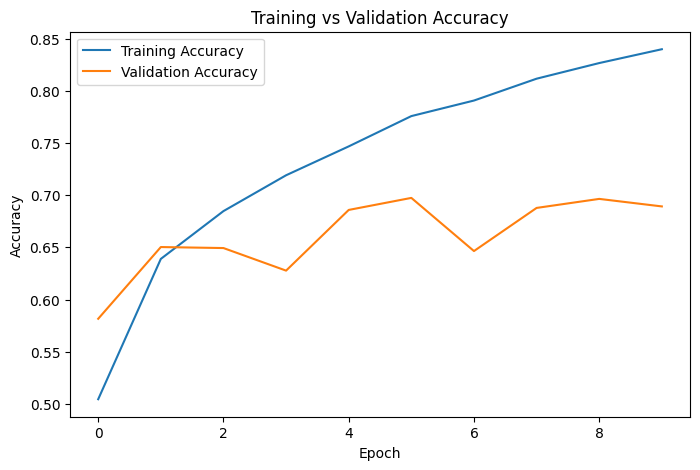

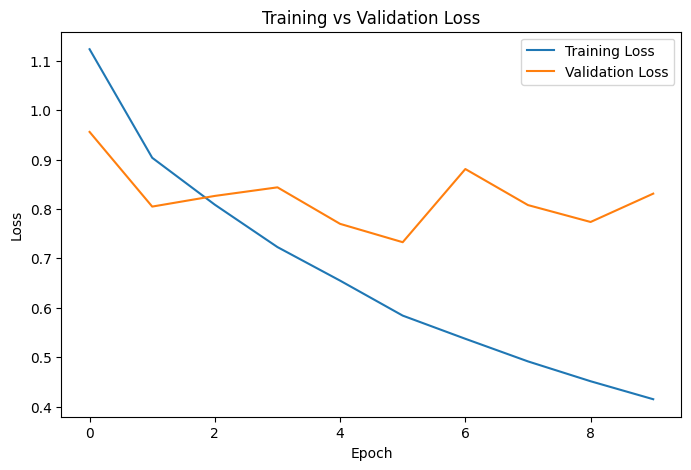

65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step
    Actual  Predicted
0        0          0
1       -2         -2
2       -2         -2
3        0          1
4        0          0
5        0          0
6       -1         -1
7       -2         -2
8        0          0
9        0          0
10      -1         -1
11       0          0
12      -1         -1
13      -2         -2
14       0          0
15      -1         -1
16      -1         -1
17      -2         -2
18       0          0
19       0          0
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


,posts,predicted,intensity,Predicted
0,I know as parent of child with down syndrome t...,negative,-1,-1
1,tomorrow sept 9 will be one year since I leave...,negative,-1,-1
2,I start with severe headache in jan and was fo...,negative,-1,-1
3,ok so I was look up to see why my gum were ble...,negative,-1,-1
4,hi I m 15 and was just diagnose with leukemia ...,negative,-1,-1
5,mandy is only 24 she is such a sweet friend he...,negative,-1,-1
6,I am a new member and hope to find some suppor...,negative,-1,-1
7,so my new illne lymphoma start out as flesh ea...,negative,-1,-1
8,my brother was diagnose with leukemia about a ...,negative,-1,-2
9,I have mylefibrosis which turn to leukemia the...,negative,-1,1


In [25]:

loss, accuracy =glove_gru.evaluate(X_test_pad, y_test)
print("GLOVE + GRU Accuracy:", accuracy)

sample_clean = """its been 2 year and like many it was the first very personal relationship I have with a girl to this day I always say that she pass away from cancer leukemia to be exact yes she have leukemia apparently she s do much well now but our relationship was difficult I do not know about how a womans mind work but I know its very complex and can be influence by her close friend and family ever since than all the happy thought new beginning and even new emotion have all disappear I think that this was something very special an answer to many thing she was teach I in a way she was show I compassion and kindness which lead I to do great thing and even help society but that christmas morning ruin everything I am strong now after a couple fail relationship I realize I am not humane enough to deal with relationship I am still bitter in a way all the thing I go through to keep someone alot of people happy I have nothing to show for i d give more detail about my past relationship but its not for the public its a personal ordeal I know there are other here who have been through the same or even bad but like the title say I am new to this particular support group I do not know what solution I may find but at least I will not be talk to myself about"""
sample_sequence = tokenizer.texts_to_sequences([sample_clean])
from tensorflow.keras.preprocessing.sequence import pad_sequences
sample_padded = pad_sequences(
    sample_sequence,
    maxlen=200
)
prediction = glove_gru.predict(sample_padded)
predicted_class = np.argmax(prediction, axis=1)
predicted_label = le.inverse_transform(predicted_class)
print("Predicted Label:" , predicted_label[0])


from sklearn.metrics import classification_report
y_pred_prob =glove_gru.predict(X_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)
print(classification_report(y_test, y_pred))

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)


import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(history_glove_gru.history['accuracy'], label='Training Accuracy')
plt.plot(history_glove_gru.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()


plt.figure(figsize=(8,5))
plt.plot(history_glove_gru.history['loss'], label='Training Loss')
plt.plot(history_glove_gru.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

pred =glove_gru.predict(X_test_pad)
pred_labels = np.argmax(pred, axis=1)
predicted = le.inverse_transform(pred_labels)
actual = le.inverse_transform(y_test)
result = pd.DataFrame({
    "Actual": actual,
    "Predicted": predicted
})
print(result.head(20))



test_df = pd.read_excel("test_data.xlsx")
test_df = test_df.dropna()
test_text = test_df["posts"].apply(lambda x: " ".join(x) if isinstance(x, list) else str(x))
seq = tokenizer.texts_to_sequences(test_text)
pad = pad_sequences(seq, maxlen=100)
pred = glove_gru.predict(pad)
pred_labels = np.argmax(pred, axis=1)
test_df["Predicted"] = le.inverse_transform(pred_labels)
test_df


In [36]:
glove_gru.save("glove_gru.keras")

In [37]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [38]:
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)